### Import modules

In [1]:
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

### Load the cleaned dataset

In [ ]:
cleaned_df = pd.read_csv(r"C:\Users\fedem\OneDrive\Desktop\Portfolio\Portfolio\Spam-Detector\data\processed\sms_cleaned.csv")

In [17]:
cleaned_df.head(10)

,message,label
0,"Go until jurong point, crazy.. Available only ...",0
1,Ok lar... Joking wif u oni...,0
2,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,U dun say so early hor... U c already then say...,0
4,"Nah I don't think he goes to usf, he lives aro...",0
5,FreeMsg Hey there darling it's been 3 week's n...,1
6,Even my brother is not like to speak with me. ...,0
7,As per your request 'Melle Melle (Oru Minnamin...,0
8,WINNER!! As a valued network customer you have...,1
9,Had your mobile 11 months or more? U R entitle...,1


### Build the model and perform hyperparameter tuning using Grid Search

In [ ]:
X = cleaned_df["message"]
y = cleaned_df["label"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

pipeline = Pipeline([
    ("vectorizer", TfidfVectorizer()),
    ("classifier", MultinomialNB())
])

param_grid = [
    {
        "vectorizer": [TfidfVectorizer()],
        "vectorizer__lowercase": [True],
        "vectorizer__stop_words": [None, "english"],
        "vectorizer__max_features": [3000, 5000, 10000],
        "vectorizer__ngram_range": [(1, 1), (1, 2)],
        "classifier": [MultinomialNB()],
        "classifier__alpha": [0.01, 0.1, 0.5, 1.0]
    },
    {
        "vectorizer": [CountVectorizer()],
        "vectorizer__lowercase": [True],
        "vectorizer__stop_words": [None, "english"],
        "vectorizer__max_features": [3000, 5000, 10000],
        "vectorizer__ngram_range": [(1, 1), (1, 2)],
        "classifier": [MultinomialNB()],
        "classifier__alpha": [0.01, 0.1, 0.5, 1.0]
    },
    {
        "vectorizer": [TfidfVectorizer()],
        "vectorizer__lowercase": [True],
        "vectorizer__stop_words": [None, "english"],
        "vectorizer__max_features": [3000, 5000, 10000],
        "vectorizer__ngram_range": [(1, 1), (1, 2)],
        "classifier": [LogisticRegression(max_iter=1000, class_weight="balanced", solver="liblinear")],
        "classifier__C": [0.01, 0.1, 1.0, 10.0]
    },
    {
        "vectorizer": [CountVectorizer()],
        "vectorizer__lowercase": [True],
        "vectorizer__stop_words": [None, "english"],
        "vectorizer__max_features": [3000, 5000, 10000],
        "vectorizer__ngram_range": [(1, 1), (1, 2)],
        "classifier": [LogisticRegression(max_iter=1000, class_weight="balanced", solver="liblinear")],
        "classifier__C": [0.01, 0.1, 1.0, 10.0]
    },
]

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring="f1",
    cv=cv,
    n_jobs=-1,
    verbose=2
)

grid_search.fit(X_train, y_train)

print("Best parameters:")
print(grid_search.best_params_)

print("\nBest cross-validation F1:")
print(grid_search.best_score_)

Fitting 5 folds for each of 192 candidates, totalling 960 fits
Best parameters:
{'classifier': MultinomialNB(), 'classifier__alpha': 1.0, 'vectorizer': CountVectorizer(), 'vectorizer__lowercase': True, 'vectorizer__max_features': 10000, 'vectorizer__ngram_range': (1, 1), 'vectorizer__stop_words': None}

Best cross-validation F1:
0.95448869107886


### Print the classification report for the best model

In [31]:
best_model = grid_search.best_estimator_

y_pred = best_model.predict(X_test)

print(classification_report(y_test, y_pred, target_names=["NotSpam", "Spam"]))

              precision    recall  f1-score   support

     NotSpam       0.99      0.99      0.99       966
        Spam       0.96      0.91      0.94       149

    accuracy                           0.98      1115
   macro avg       0.98      0.95      0.96      1115
weighted avg       0.98      0.98      0.98      1115



### Plot the confusion matrix

<Axes: >

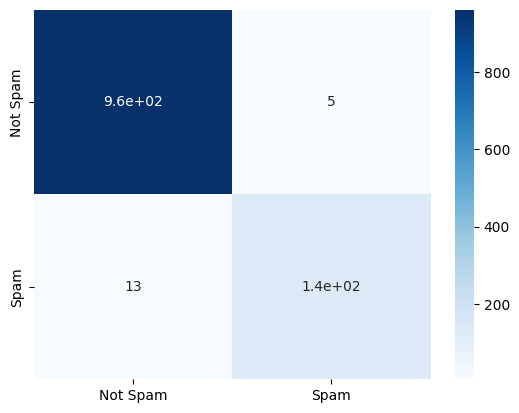

In [ ]:
confusion_matrix = confusion_matrix(y_test, y_pred)
sns.heatmap(confusion_matrix, annot=True, cmap="Blues", xticklabels=["Not Spam", "Spam"], yticklabels=["Not Spam", "Spam"])
plt.xlabel("True labels")
plt.ylabel("Predicted labels")